# jaxsp Tutorial

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['savefig.bbox'] = 'tight'


In [3]:
import jaxsp as jsp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


jaxsp uses the unit convention used in [Schive2014](https://arxiv.org/abs/1406.6586).
Concordance parameters are chosen as in [gravsphere](https://github.com/justinread/gravsphere), see `constants.py` and `units.py`for exact defintions in jaxsp github. 

# m22 here is the mass of the axion $\times 10^{-22}$ eV

u has attributes from_[unit] and to_[unit] to change between units - 10 * u.from_Msun means change 10[$M_{sun}$] to code units

In [4]:
m22 = 1.0
u = jsp.set_schroedinger_units(m22)

### Input Density Profiles - Obtains $\rho_{cNFWt}$

~~~
def core_nfw_tides_rho(r, params):
    """Density of the cNFWt profile"""
    M200 = params.M200
    g = params.g
    rc = params.rc
    n = params.n
    rt = params.rt
    delta = params.delta
    rs = params.rs
    rho0 = params.rho0

    return jnp.piecewise(
        r,
        [r < rt],
        [
            lambda r: _rho_cNFW(
                r, n, rc, _rho_NFW(r, rho0, rs), _M_NFW(r, M200, g, rs)
            ),
            lambda r: _rho_cNFW(
                rt, n, rc, _rho_NFW(rt, rho0, rs), _M_NFW(rt, M200, g, rs)
            )
            * (r / rt) ** (-delta),
        ],
    )


rho = core_nfw_tides_rho

~~~

In [5]:
rho = jax.vmap(jsp.rho, in_axes=(0,None))

# rho is a function we can input array r and parameter values to get the density

## Params are $M_{200}$, c, n, $r_c$, $r_t$, $\delta$
## [$3.57964808 \times 10^8 [M_{sun}]$, 25.690207, 0.407461, 0.012570 [Kpc], 1.857991 [Kpc], 3.729259]


### How do they get params? Through Jeans Modelling of Leo II?

In [6]:
cNFWtides_params = jnp.array([
    357964808.148399 * u.from_Msun, 
    25.690207, 
    0.407461, 
    0.012670 * u.from_Kpc, 
    1.857991 * u.from_Kpc, 
    3.729259
])
density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)
r99 = jsp.enclosing_radius(0.99, density_params) # radius that encloses 99% of mass
print(r99)
density_params

20.743367613524313


core_NFW_tides_params:
	name=236146193804778771,
	M200=1118.7951678146808,
	c=25.690207,
	n=0.407461,
	rc=0.0005960840778498662,
	rt=0.0874126954923718,
	delta=3.729259,
    Derived:
	rs=0.026822448297135815,
	g=0.4307070628318999,
	rho0=1987135.4034031027,

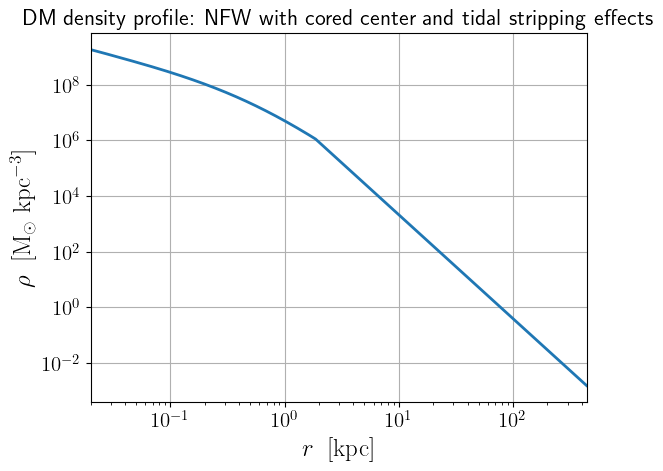

In [19]:
fig, ax = plt.subplots()
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(20 * u.from_pc), jnp.log10(r99), 1000)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun/u.to_Kpc**3)
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('DM density profile: NFW with cored center and tidal stripping effects', fontsize = 16)
plt.show()



### Gravitational Potential - Function which outputs potential given r and params

Found by doing integration of $M_{cNFWt}$ using Gauss-Legendre quadrature

In [8]:
potential = jax.vmap(jsp.potential, in_axes=(0,None))

In [9]:
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
N = 512
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N) 
potential_params

potential_params:
	name=354410778964585829,
	density_params=236146193804778771,
	N=512,
	rmin=4.704688854379371e-06,
	rmax=488.5326223948342,

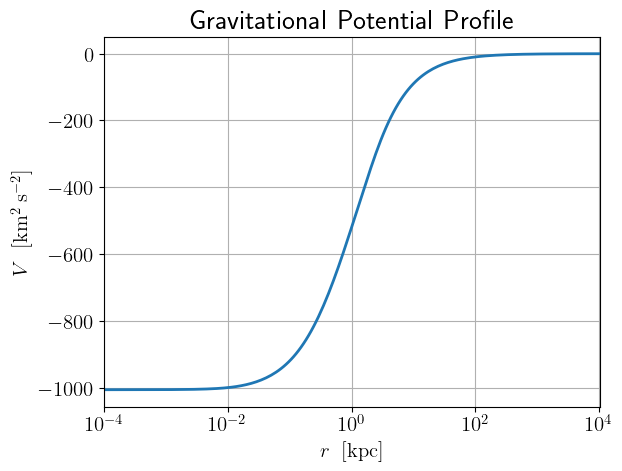

In [10]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 200)
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2)
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)

ax.set_title('Gravitational Potential Profile', fontsize = 20)
plt.show()

# Eigenstate Library

## 1) Creating vmap which can evaluate the library once we ave $t_{nl}$. 
Getting parameters a and b and converting $t_{nl}$ into $r^{-1}u_{nl}$ as $t_{nl}(x) = u_{nl}\sqrt{\frac{b}{r} + a}$

~~~
def eval_radial_eigenmode(r, radial_eigenmode_params):
    a = radial_eigenmode_params.a
    b = radial_eigenmode_params.b
    x = x_of_r(r, a, b)
    return eval_eigenmode(x, radial_eigenmode_params.eigenmode_params) / jnp.sqrt(
        b * r + a * r**2
    )

In [11]:
eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

## 2) Setting rmin, rmax, N = number of domain partitions, a and b

## 3) Initialise eigenstate library

~~~
def init_eigenstate_library(potential_params r_min, r_max, a, b, N, batch_size=16, potential=gravitational_potential):

    init_radial_eigenmodes = jax.jit(
        map_vmap(
            init_radial_eigenmode_params,
            in_axes=(0, 0, None, None, None, None, None, None),
            batch_size=batch_size,
        ),
        static_argnames="N",
    )
    compute_all_nmax = jax.vmap(nmax, in_axes=(0, None, None, None, None, None, None))
    ll = lmax(potential_params, r_min, r_max, a, b, N, potential=potential)
    nn = compute_all_nmax(
        jnp.arange(ll), potential_params, r_min, r_max, a, b, N, potential=potential
    )

    result_shape = jax.ShapeDtypeStruct((), jnp.int64)
    name = jax.pure_callback(
        eigenstate_library.compute_name,
        result_shape,
        potential_params,
        r_min,
        r_max,
        a,
        b,
        N,
    )
    if nn.shape[0] == 0:
        return None

    ls = jnp.repeat(jnp.arange(ll), nn)
    ns = jnp.concatenate([jnp.arange(n) for n in nn])

    return eigenstate_library(
        radial_eigenmode_params=init_radial_eigenmodes(
            ls, ns, potential_params, r_min, r_max, a, b, N, potential=potential
        ),
        name=name,
        potential_params=potential_params.name,
    )


In [12]:
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.99, density_params)
N = 1024
a = 1
b = 10
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)
eigenstate_lib

eigenstate_library:
	name=720428951175803208,
	potential_params=354410778964585829,
	total number of modes=290,
	lmax=23,
	nmax=22,
	Emin=-366.4324756825,
	Emax=-2.7326364531013496

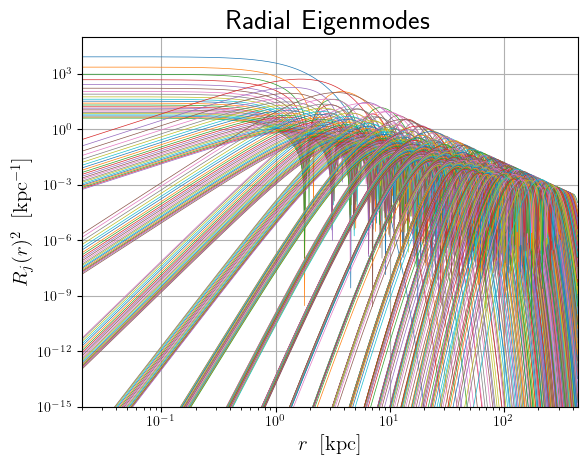

In [13]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(20 * u.from_pc), jnp.log10(rmax), 1000)
R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
ax.set_title('Radial Eigenmodes', fontsize = 20)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize = 15)
ax.plot(r * u.to_Kpc, R_j_r**2, lw=0.5)
ax.set_ylim([1e-15, 1e5])
plt.show()

### Fitting Eigen State Coefficients 

In [14]:
rho_psi = jax.vmap(jsp.rho_psi, in_axes=(0,None,None))

In [15]:
tol = 1e-7
rmin = 20 * u.from_pc
rmax = jsp.enclosing_radius(0.99, density_params)
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)
wavefunction_params

wavefunction_params:
	name=321443324063497960,
	eigenstate_library=720428951175803208,
	density_params=236146193804778771,
	aj_2=[4.006504847517604e-17, 0.6378985108831035],
	total_mass=716.415885628137,
	r_min=0.000940937770875874,
	r_max=20.743367613524313,
	distance=0.030344084526876418,

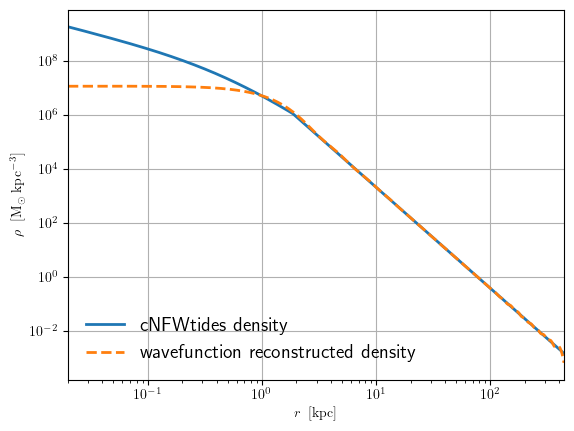

In [21]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")

r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 1000)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun / (u.to_Kpc)**3, label='cNFWtides density')
ax.plot(r * u.to_Kpc, rho_psi(r, wavefunction_params, eigenstate_lib) * u.to_Msun / (u.to_Kpc)**3, label='wavefunction reconstructed density', ls='--')
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$")
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$")
plt.legend(fontsize = 14)
plt.show()

(23, 24)


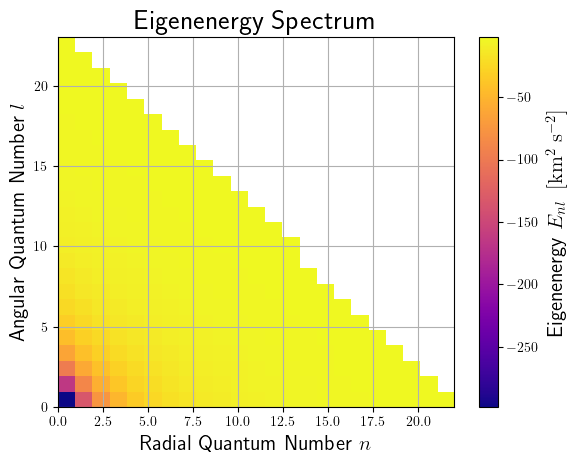

In [17]:
eigen_energies = eigenstate_lib.radial_eigenmode_params.E  # shape (Nj,)
l = eigenstate_lib.radial_eigenmode_params.l               # shape (Nj,)
l = jnp.asarray(l, dtype=int)
n = eigenstate_lib.radial_eigenmode_params.n 

def make_E_nl_matrix(eigen_energies, n, l):
    '''Make matrix of shape n,l with eigen energies as values'''
    l_max = jnp.max(l)
    E_nl = -jnp.inf * jnp.ones((n.max()+1, l_max+1))
    for i in range(eigen_energies.shape[0]):
        E_nl = E_nl.at[n[i], l[i]].set(eigen_energies[i])
    return E_nl

E_nl = make_E_nl_matrix(eigen_energies, n, l)
print(E_nl.shape)

fig, ax = plt.subplots()
ax.set_title('Eigenenergy Spectrum', fontsize = 20)
im = ax.imshow(E_nl.T * u.to_kms**2, origin='lower', aspect='auto',
               extent=[0, E_nl.shape[0]-1, 0, E_nl.shape[1]-1],
               cmap='plasma')
ax.set_xlabel(r"Radial Quantum Number $n$", fontsize = 15)
ax.set_ylabel(r"Angular Quantum Number $l$", fontsize = 15)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Eigenenergy $E_{nl} \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
plt.show()



### Volume Render (Experimental)

In [ ]:
# !pip install yt

In [ ]:
import yt
from yt.visualization.volume_rendering.api import (
    Scene, 
    Camera, 
    TransferFunctionHelper, 
    create_volume_source
)
from scipy.interpolate import NearestNDInterpolator
import s2fft

In [ ]:
@jax.vmap
def rthetaphi_from(xyz):
    xy = xyz[0]**2 + xyz[1]**2
    r = jnp.sqrt(xy + xyz[2]**2)
    theta = jnp.arctan2(jnp.sqrt(xy), xyz[2]) 
    phi = jnp.arctan2(xyz[1], xyz[0])
    return jnp.array([r,theta,phi])

@jax.vmap
def xyz_from(rthetaphi):
    r, theta, phi = rthetaphi[0],rthetaphi[1],rthetaphi[2],
    x = r*jnp.cos(phi) * jnp.sin(theta)
    y = r*jnp.sin(phi) * jnp.sin(theta)
    z = r*jnp.cos(theta)
    return jnp.array([x,y,z])

def cartesian_product(*vecs):
    def cartesian_product(a, b):
        return jax.vmap(
            lambda a, b: jnp.c_[a * jnp.ones(b.shape[0]), b], in_axes=(0, None)
        )(a, b).reshape(-1, a.ndim + b.ndim)

    axb = cartesian_product(vecs[-2], vecs[-1])
    for vec in reversed(vecs[:-2]):
        axb = cartesian_product(vec, axb)
    return axb

In [ ]:
N = 256
R = 0.98 * wavefunction_params.r_fit
dx = 2*R/N
print(dx)
x = y = z = dx * jnp.arange(N) + dx / 2 - R


xyz = cartesian_product(x,y,z)
rthetaphi = rthetaphi_from(xyz)

0.1588164082910455


In [ ]:
L = (eigenstate_lib.radial_eigenmode_params.l[-1]+1).item()
nside = L//2
R = 0.98 * wavefunction_params.r_fit
r = jnp.linspace(wavefunction_params.r_min, R, 512)
theta = s2fft.sampling.s2_samples.thetas(L, sampling="healpix", nside=nside)
phi = [s2fft.sampling.s2_samples.phis_ring(t, nside) for t in range(theta.shape[0])]
phi_len = jnp.array([p.shape[0] for p in phi])
theta = jnp.repeat(theta, phi_len)
phi = jnp.concatenate(phi)
theta_phi = jnp.c_[theta, phi]
psi_new_batch = jax.jit(jax.vmap(jsp.psi, in_axes=(0,None,None,None,None,None)), static_argnums=(3,4))

psi2_healpix = jnp.abs(psi_new_batch(r, wavefunction_params, eigenstate_lib, 
                          eigenstate_lib.radial_eigenmode_params.l[-1].item(), 
                          jnp.max(eigenstate_lib.radial_eigenmode_params.n).item(),
                          jax.random.PRNGKey(42)))**2
xyz_exact = xyz_from(cartesian_product(r, theta_phi))
psi2_interp = NearestNDInterpolator(xyz_exact, psi2_healpix.flatten())

In [ ]:
psi2_xyz = psi2_interp(xyz).reshape(N,N,N)


KeyboardInterrupt: 

In [ ]:
ds = yt.load_uniform_grid(
    dict(density=psi2_xyz * u.to_Msun/u.to_Kpc**3),
    [N,N,N],
    bbox=np.array([[-R, R], [-R, R], [-R, R]]) * u.to_Kpc,
    length_unit="kpc",
    mass_unit="Msun"
)

yt : [INFO     ] 2025-11-17 09:04:44,146 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-11-17 09:04:44,149 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2025-11-17 09:04:44,151 Parameters: domain_left_edge          = [-432.0902166 -432.0902166 -432.0902166]
yt : [INFO     ] 2025-11-17 09:04:44,152 Parameters: domain_right_edge         = [432.0902166 432.0902166 432.0902166]
yt : [INFO     ] 2025-11-17 09:04:44,153 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2025-11-17 09:04:45,080 Rendering scene (Can take a while).
yt : [INFO     ] 2025-11-17 09:04:45,109 Creating volume


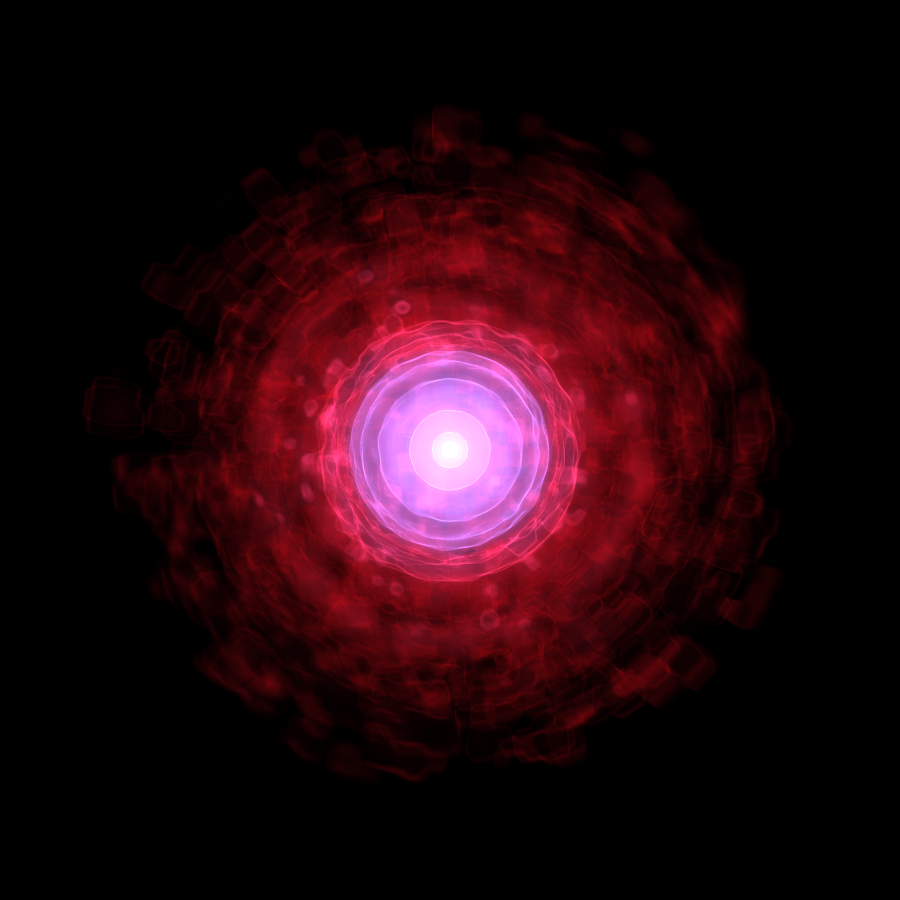

In [ ]:
ds_section = ds.sphere(ds.domain_center,((R * u.to_Kpc).item(),"kpc"))
sc = yt.create_scene(ds_section, ("stream", "density"), "perspective")
source = sc.get_source()
source.set_log(True)
bounds=(1e-2, 3e5)
    
tf = yt.ColorTransferFunction(np.log10(bounds), grey_opacity=False)

def quadramp(vals, minval, maxval):
    return ((vals - vals.min()) / (vals.max() - vals.min()))**0.5

tf.map_to_colormap(
    np.log10(bounds[0]), np.log10(bounds[1]), 
    colormap="gist_stern", 
    scale_func=quadramp
)
tf.add_layers(8,
              colormap="gist_stern", 
              alpha=np.geomspace(1, 6, 8))

source.tfh.tf = tf
source.tfh.bounds = bounds

camera = sc.camera
camera.position = [1.,0,0]
camera.resolution = (900,900)
camera.zoom(1.)

camera.switch_orientation()
sc.show(sigma_clip=3.)

In [ ]:
l_max = jnp.max(eigenstate_lib.radial_eigenmode_params.l).item()
n_max = jnp.max(eigenstate_lib.radial_eigenmode_params.n).item()

N = 256
R = 0.98 * wavefunction_params.r_fit
dx = 2*R/N
print(dx)
x = y = z = dx * jnp.arange(N) + dx / 2 - R

xyz = cartesian_product(x,y,z)
rthetaphi = rthetaphi_from(xyz)

r = rthetaphi[:,0]
theta = rthetaphi[:,1]
phi = rthetaphi[:,2]


x = jsp.psi_exact(r, theta, phi, wavefunction_params, eigenstate_lib, l_max, n_max, key=jax.random.PRNGKey(0))

0.1588164082910455


: 